# Setup and Imports
Run this cell first to initialize the graph and environment.

In [3]:
import sys
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to the path so we can import graphalp
sys.path.append(os.path.abspath('../src'))

from graphalp.active_learning import HarmonicGreedySampler
from graphalp.label_propagation import HarmonicLabelPropagator

# Simulation setup
n_rows, n_cols = 20, 20
G = nx.grid_2d_graph(n_rows, n_cols)
nodes = list(G.nodes())

# Synthetic labels: 1 if row < n_rows/2, else 0
true_labels = {node: 1 if node[0] < n_rows / 2 else 0 for node in nodes}

print(f"Graph created with {len(nodes)} nodes.")

Graph created with 400 nodes.


### Step-by-Step Active Learning Visualization
In this section, we will visualize the grid after each sampling decision. The 'Risk' (uncertainty) is shown as a heatmap, and the stars indicate the nodes selected by the algorithm at each specific step.

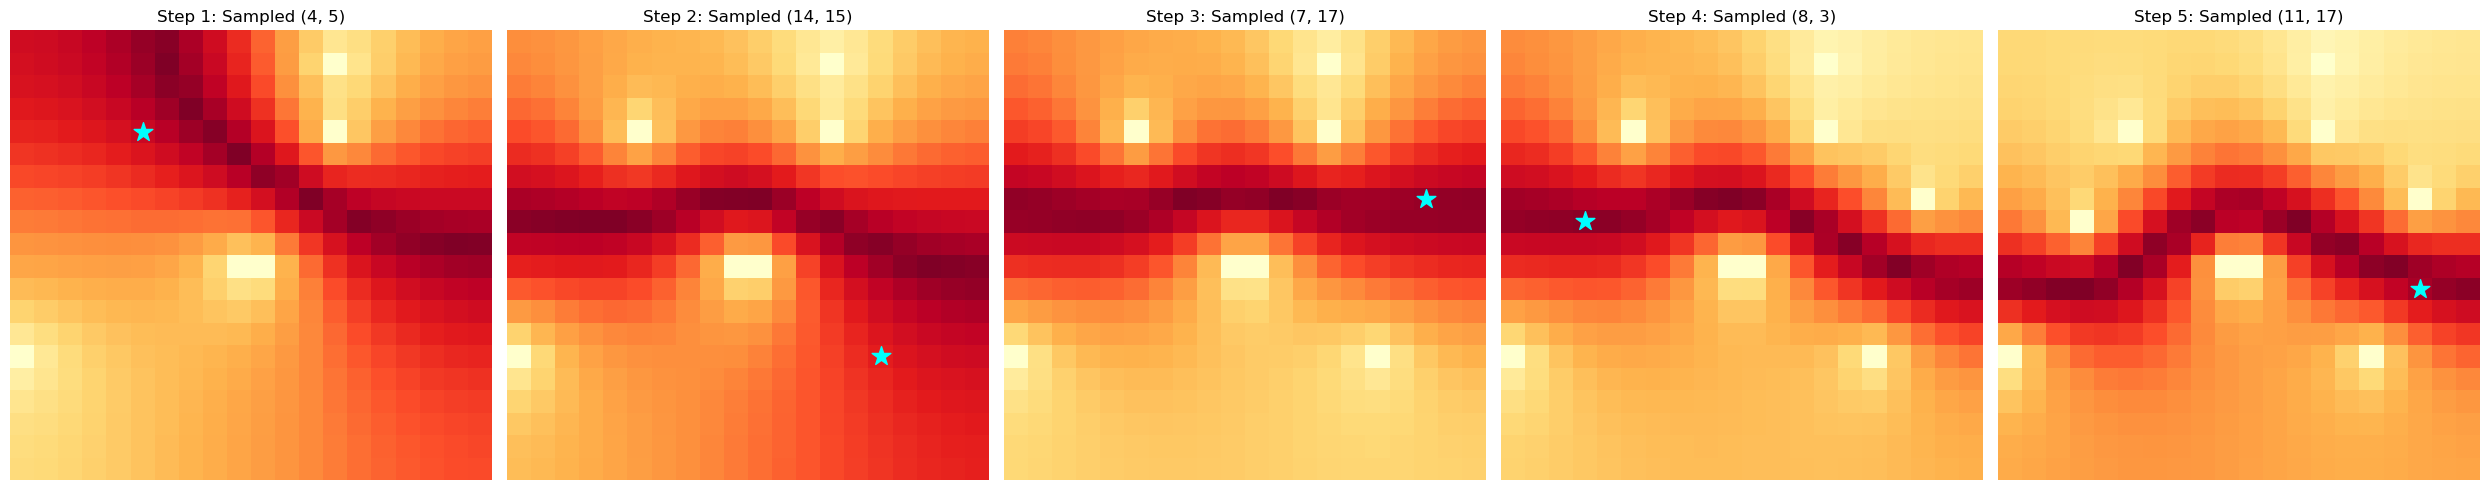

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the simulation
np.random.seed(42)
initial_indices = np.random.choice(len(nodes), 5, replace=False)
step_labels = {nodes[i]: true_labels[nodes[i]] for i in initial_indices}
sampler = HarmonicGreedySampler(G)

steps_to_show = 5
fig, axes = plt.subplots(1, steps_to_show, figsize=(25, 5))

for step in range(steps_to_show):
    # 1. Fit and find next node
    sampler.fit(list(step_labels.keys()), list(step_labels.values()))
    next_node = sampler.sample()

    # 2. Prepare risk grid for visualization
    risk_grid = np.zeros((n_rows, n_cols))
    for i, u_idx in enumerate(sampler.model.u_idx):
        node = sampler.model.nodes[u_idx]
        prob = np.clip(sampler.model.f_u[i], 0.0, 1.0)
        risk_grid[node[0], node[1]] = min(prob, 1 - prob)

    # 3. Plot
    ax = axes[step]
    sns.heatmap(risk_grid, cmap='YlOrRd', ax=ax, cbar=False)
    ax.scatter(next_node[1] + 0.5, next_node[0] + 0.5, color='cyan', marker='*', s=200, label='Selected')
    ax.set_title(f'Step {step+1}: Sampled {next_node}')
    ax.axis('off')

    # 4. Update labels for next iteration
    step_labels[next_node] = true_labels[next_node]

plt.tight_layout()
plt.show()

### High-Density Sampling Visualization (90% Labeled)
We will now run the simulation until only 10 nodes (10%) remain unlabeled. This requires 85 active learning steps starting from our 5 initial labels. We will display a snapshot of the graph after each step.

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
import imageio.v2 as imageio
import io
from PIL import Image

# Setup for 20x20 simulation
np.random.seed(42)
initial_indices = np.random.choice(len(nodes), 5, replace=False)
step_labels = {nodes[i]: true_labels[nodes[i]] for i in initial_indices}
sampler = HarmonicGreedySampler(G)

# Reduced to 50 steps as requested
total_steps = 50
frames = []

print(f"Running {total_steps} steps and generating GIF...")

for step in range(total_steps):
    sampler.fit(list(step_labels.keys()), list(step_labels.values()))
    next_node = sampler.sample()

    # Prepare risk grid
    risk_grid = np.zeros((n_rows, n_cols))
    for i, u_idx in enumerate(sampler.model.u_idx):
        node = sampler.model.nodes[u_idx]
        prob = np.clip(sampler.model.f_u[i], 0.0, 1.0)
        risk_grid[node[0], node[1]] = min(prob, 1 - prob)

    # Create plot for the current frame
    fig = plt.figure(figsize=(8, 7))
    sns.heatmap(risk_grid, cmap='YlOrRd', alpha=0.6, cbar=True)

    pos_heatmap = {node: (node[1] + 0.5, node[0] + 0.5) for node in G}
    nx.draw_networkx_edges(G, pos_heatmap, alpha=0.1)

    labeled_nodes = [n for n in step_labels]
    node_colors = ['blue' if step_labels[n] == 0 else 'orange' for n in labeled_nodes]
    if labeled_nodes:
        nx.draw_networkx_nodes(G, pos_heatmap, nodelist=labeled_nodes,
                               node_size=30, node_color=node_colors)

    nx.draw_networkx_nodes(G, pos_heatmap, nodelist=[next_node],
                           node_size=150, node_color='cyan', node_shape='*')

    plt.title(f"Step {step+1}: Sampled {next_node}")
    plt.axis('off')

    # Save plot to a buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)

    # Open with PIL and resize to a consistent size to ensure mimsave doesn't fail
    img = Image.open(buf).convert('RGB')
    if step == 0:
        target_size = img.size
    else:
        img = img.resize(target_size, Image.Resampling.LANCZOS)

    frames.append(np.array(img))
    plt.close(fig)

    # Update labels
    step_labels[next_node] = true_labels[next_node]

# Save the frames as a GIF
imageio.mimsave('active_learning.gif', frames, fps=2)
print("GIF saved as active_learning.gif")

Running 50 steps and generating GIF...
GIF saved as active_learning.gif
